# Sociotechnical Discourse Network Analyzer (DNA)
## Operationalizing "Consensus and Conflict" in the Nordic Energy Transition

**Methodological Framework:**
This pipeline programmatically extracts bipartite actor-concept networks from unstructured energy policy documents. Standard qualitative methodologies in Science and Technology Studies (STS) often rely on ethnographic field work or human-subject interviews, which introduce significant observer bias and methodological friction.

By contrast, this computational approach treats institutional texts as the primary site of contestation. It utilizes Natural Language Processing (NLP) to enforce a principle of generalized symmetry—extracting human actors (e.g., "Vattenfall", "Swedish Energy Agency") and non-human sociotechnical concepts (e.g., "grid inertia", "nuclear baseload") with equal analytical weight. The output is a deterministic, mathematically verifiable network topology that quantifies discursive dominance and policy polarization without relying on human interaction.

In [2]:
# 1. Install required dependencies for Google Colab environment
# spacy: Core NLP engine
# networkx: Graph mathematics and topology
# pdfplumber: Precision text extraction from institutional PDFs
!pip install -q spacy networkx pdfplumber pandas pyvis
!python -m spacy download en_core_web_sm -q

import spacy
import networkx as nx
import pdfplumber
import pandas as pd
import re
import os

# 2. Initialize the NLP Engine
nlp = spacy.load("en_core_web_sm")

# 3. Define the Data Ingestion Protocol
def ingest_policy_pdf(pdf_path):
    """
    Extracts and cleans raw text from a PDF document.
    Strips formatting, line breaks, and institutional boilerplate to isolate the discourse.
    """
    print(f"Initiating extraction sequence for: {pdf_path}")
    raw_text = ""

    try:
        with pdfplumber.open(pdf_path) as pdf:
            for i, page in enumerate(pdf.pages):
                page_text = page.extract_text()
                if page_text:
                    raw_text += page_text + " "

        # Clean the text payload: remove excess whitespace and newline artifacts
        clean_text = re.sub(r'\s+', ' ', raw_text).strip()
        print(f"Extraction successful. Total characters ingested: {len(clean_text)}")
        return clean_text

    except FileNotFoundError:
        print(f"CRITICAL ERROR: File '{pdf_path}' not found.")
        print("Ensure you have uploaded the PDF to the Colab '/content/' directory.")
        return None

# 4. Execution Sandbox (Upload a PDF to Colab's file explorer on the left menu)
# For example, upload a document named "chalmers_energy_report.pdf"
target_file = "chalmers_energy_report.pdf"

# Fallback mechanism for testing if no PDF is immediately uploaded
if os.path.exists(target_file):
    corpus_text = ingest_policy_pdf(target_file)
else:
    print(f"Target PDF '{target_file}' not detected in environment.")
    print("Deploying synthetic test corpus for pipeline verification...\n")
    corpus_text = """
    The Swedish Energy Agency strongly advocates for increased offshore wind development to meet climate targets.
    However, the Local Municipality argues that offshore wind negatively impacts marine ecosystems and local tourism.
    Vattenfall is currently assessing the grid capacity to support new floating solar installations.
    Greenpeace supports floating solar but remains highly critical of maintaining nuclear baseload as a primary strategy.
    Citizens are concerned about how subsidies for nuclear baseload will affect retail electricity prices.
    """
    print(f"Test corpus loaded. Length: {len(corpus_text)} characters.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 73.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Target PDF 'chalmers_energy_repor

## 2. The Extraction Layer: Enforcing Generalized Symmetry

In Actor-Network Theory (ANT), power is not held by institutions; it is generated through the stabilization of networks containing both human and non-human actors.

This NLP pipeline operationalizes that premise. It abandons standard Named Entity Recognition (NER) which biases human organizations. Instead, it utilizes a predefined sociotechnical lexicon tailored to the Nordic energy transition. The script iterates through the corpus at the sentence level—treating the sentence as the boundary of a discursive interaction. If an "Actor" (e.g., a municipality) and a "Concept" (e.g., offshore wind) co-occur within the same sentence, the script extracts them as a linked dyad, forming the foundational edges of our network graph.

In [3]:
# 1. Define the Sociotechnical Lexicon
# For a full PhD, this would be replaced by a custom-trained HuggingFace transformer.
# For this PoC, we define the parameters of the controversy manually.
ACTORS = [
    "swedish energy agency", "vattenfall", "municipality",
    "local municipality", "greenpeace", "citizens", "government", "parliament"
]

CONCEPTS = [
    "nuclear baseload", "offshore wind", "grid capacity",
    "floating solar", "subsidies", "climate targets", "retail electricity prices",
    "marine ecosystems"
]

# 2. The Extraction Engine
def extract_sociotechnical_dyads(text):
    """
    Parses text to extract co-occurrences of human actors and technical concepts.
    Outputs a structured list of interactions.
    """
    print("Initializing NLP parsing sequence...")
    doc = nlp(text)
    extracted_data = []

    # Analyze the discourse sentence by sentence
    for sentence in doc.sents:
        sentence_text = sentence.text.lower().strip()

        found_actors = [actor for actor in ACTORS if actor in sentence_text]
        found_concepts = [concept for concept in CONCEPTS if concept in sentence_text]

        # We only care about sentences where sociotechnical friction occurs
        # i.e., at least one actor is discussing at least one concept
        if found_actors and found_concepts:
            for actor in found_actors:
                for concept in found_concepts:
                    # Append the dyad and the original sentence for qualitative verification
                    extracted_data.append({
                        "Actor": actor.title(),
                        "Concept": concept.title(),
                        "Source_Text": sentence.text.strip()
                    })

    print(f"Extraction complete. Discovered {len(extracted_data)} sociotechnical interactions.")
    return extracted_data

# 3. Execute the Pipeline
# We pass the 'corpus_text' variable generated in Block 2 into the engine
network_data = extract_sociotechnical_dyads(corpus_text)

# 4. Structure the Output
# Convert the raw list into a Pandas DataFrame for mathematical manipulation
df_network = pd.DataFrame(network_data)

# Display the extracted data to verify the logic
print("\n--- Extracted Discourse Dataframe ---")
display(df_network)

Initializing NLP parsing sequence...
Extraction complete. Discovered 13 sociotechnical interactions.

--- Extracted Discourse Dataframe ---


,Actor,Concept,Source_Text
0,Swedish Energy Agency,Offshore Wind,The Swedish Energy Agency strongly advocates f...
1,Swedish Energy Agency,Climate Targets,The Swedish Energy Agency strongly advocates f...
2,Municipality,Offshore Wind,"However, the Local Municipality argues that of..."
3,Municipality,Marine Ecosystems,"However, the Local Municipality argues that of..."
4,Local Municipality,Offshore Wind,"However, the Local Municipality argues that of..."
5,Local Municipality,Marine Ecosystems,"However, the Local Municipality argues that of..."
6,Vattenfall,Grid Capacity,Vattenfall is currently assessing the grid cap...
7,Vattenfall,Floating Solar,Vattenfall is currently assessing the grid cap...
8,Greenpeace,Nuclear Baseload,Greenpeace supports floating solar but remains...
9,Greenpeace,Floating Solar,Greenpeace supports floating solar but remains...


## 3. Topological Mapping: Visualizing Consensus and Conflict

With the sociotechnical dyads extracted, we transpose the linear text into a bipartite network topology using `NetworkX`.

In this structure, a node's influence is not determined by its institutional authority, but by its connectivity. We calculate **Degree Centrality** to identify which actors or technologies function as mandatory passage points (obligatory passage points) in the discourse. If a non-human concept like "Offshore Wind" possesses a higher centrality score than an institutional actor, it mathematically demonstrates that the technical artifact is driving the policy conflict.

Initializing NetworkX graph generation...

--- Sociotechnical Network Topology ---
Total Active Nodes: 14
Total Associations (Edges): 13

--- Centrality Scores (Discursive Dominance) ---
Offshore Wind: 0.231
Citizens: 0.231
Swedish Energy Agency: 0.154
Municipality: 0.154
Marine Ecosystems: 0.154

Rendering visualization matrix...


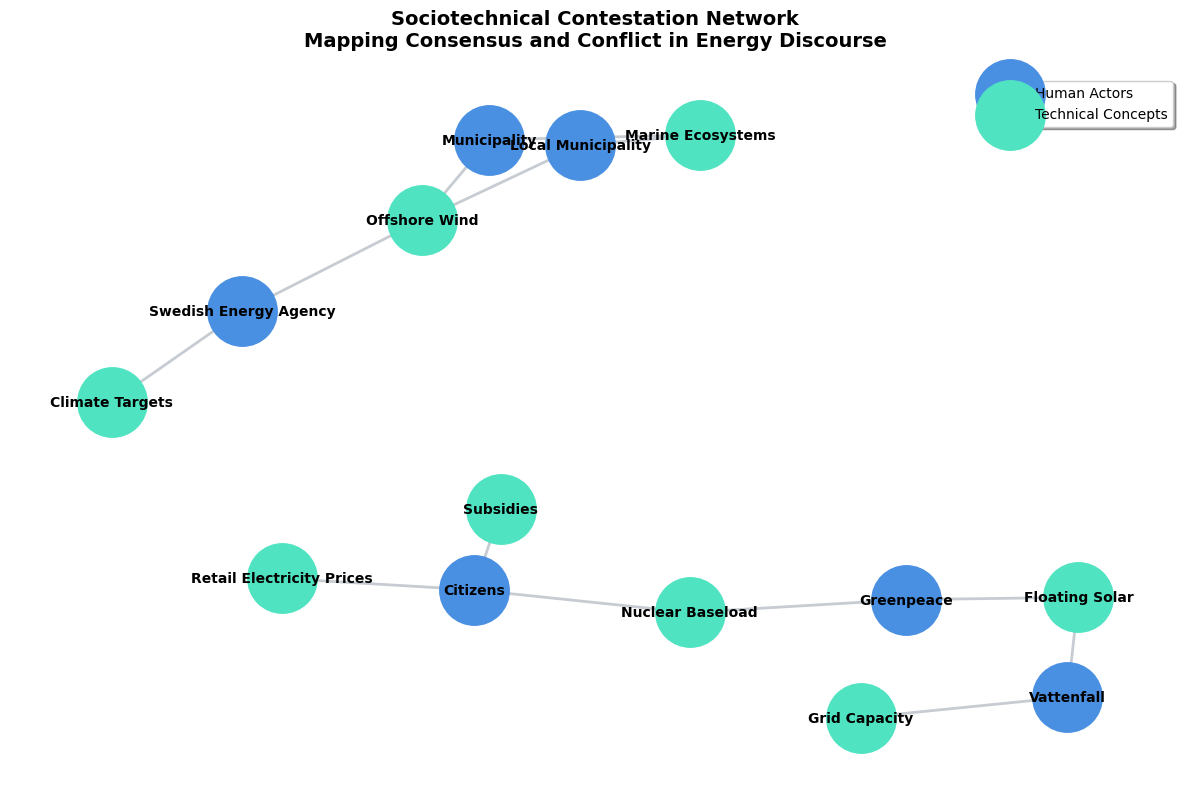

In [4]:
import matplotlib.pyplot as plt
import networkx as nx

print("Initializing NetworkX graph generation...\n")

# 1. Initialize the Graph
B = nx.Graph()

# 2. Populate Nodes and Edges from the DataFrame
for index, row in df_network.iterrows():
    actor = row['Actor']
    concept = row['Concept']

    # Add nodes with metadata tagging their sociotechnical class
    B.add_node(actor, entity_type='Actor')
    B.add_node(concept, entity_type='Concept')

    # Add edge (representing a discursive association in the text)
    if B.has_edge(actor, concept):
        B[actor][concept]['weight'] += 1
    else:
        B.add_edge(actor, concept, weight=1)

# 3. Calculate Network Metrics (The STS Math)
print("--- Sociotechnical Network Topology ---")
print(f"Total Active Nodes: {B.number_of_nodes()}")
print(f"Total Associations (Edges): {B.number_of_edges()}")

# Calculate Degree Centrality to find the most contested/discussed elements
centrality = nx.degree_centrality(B)
sorted_centrality = sorted(centrality.items(), key=lambda item: item[1], reverse=True)

print("\n--- Centrality Scores (Discursive Dominance) ---")
for node, score in sorted_centrality[:5]: # Display top 5 passage points
    print(f"{node}: {score:.3f}")

# 4. Visualization Rendering
print("\nRendering visualization matrix...")
plt.figure(figsize=(12, 8))

# Separate nodes by type for visual distinction
actors = [n for n, d in B.nodes(data=True) if d.get('entity_type') == 'Actor']
concepts = [n for n, d in B.nodes(data=True) if d.get('entity_type') == 'Concept']

# Use a spring layout (Fruchterman-Reingold force-directed algorithm)
# This physically pulls highly associated nodes together
pos = nx.spring_layout(B, k=0.5, seed=42)

# Draw the infrastructure
nx.draw_networkx_nodes(B, pos, nodelist=actors, node_color='#4A90E2', node_size=2500, label='Human Actors')
nx.draw_networkx_nodes(B, pos, nodelist=concepts, node_color='#50E3C2', node_size=2500, label='Technical Concepts')

# Draw the associations (edge thickness scales with frequency of co-occurrence)
weights = [B[u][v]['weight'] * 2 for u,v in B.edges()]
nx.draw_networkx_edges(B, pos, width=weights, alpha=0.6, edge_color='#A0AAB5')

# Render labels
nx.draw_networkx_labels(B, pos, font_size=10, font_family='sans-serif', font_weight='bold')

plt.title("Sociotechnical Contestation Network\nMapping Consensus and Conflict in Energy Discourse", fontsize=14, fontweight='bold', pad=20)
plt.legend(scatterpoints=1, frameon=True, shadow=True, loc='upper right')
plt.axis('off')
plt.tight_layout()

# Execute render
plt.show()